# 📊 Project FORESIGHT

## Notebook 02 – Exploratory Data Analysis

### Project

AI-Powered Retail Demand Forecasting & Inventory Optimization

---

### Purpose

This notebook performs exploratory data analysis on the integrated retail dataset developed in Notebook 01.

The objective is to understand sales behaviour, customer demand patterns, pricing dynamics, seasonality, and product performance.

The insights generated in this notebook will guide feature engineering and predictive modelling in subsequent notebooks.

# 🎯 Business Objective

Retail businesses generate large volumes of transactional data every day.

Understanding historical sales behaviour enables organizations to:

- Identify high-performing products
- Detect seasonal demand patterns
- Evaluate pricing behaviour
- Analyse regional sales performance
- Improve inventory planning

These insights form the foundation for developing accurate demand forecasting models.

# 📌 Notebook Objectives

The objectives of this notebook are to:

1. Explore the structure of the integrated dataset.
2. Generate descriptive statistics for key variables.
3. Analyse sales distributions and demand patterns.
4. Evaluate product, category, and store performance.
5. Investigate temporal trends and seasonality.
6. Examine the relationship between selling prices and demand.
7. Study the impact of holidays and SNAP events.
8. Generate actionable business insights to support predictive modelling.

# 🔄 Workflow

```
Integrated Dataset
        │
        ▼
Data Overview
        │
        ▼
Descriptive Analysis
        │
        ▼
Sales Exploration
        │
        ▼
Product Analysis
        │
        ▼
Store Analysis
        │
        ▼
Time Series Analysis
        │
        ▼
Business Insights
```

# ⚙️ Configuration

This section imports the required Python libraries, configures notebook settings, and defines project paths used throughout the exploratory data analysis.

The notebook processes the integrated dataset stored as chunked Parquet files to ensure efficient execution on systems with limited memory.

In [49]:
# ============================================================
# Import Required Libraries
# ============================================================

import gc
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


# 📂 Project Paths

The integrated dataset generated in Notebook 01 is stored as chunked Parquet files.

These paths are configured once and reused throughout the notebook to ensure consistency and reproducibility.

In [50]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

FINAL_CHUNK_DIR = PROCESSED_DATA_DIR / "final_chunks"

print("Project Root :", PROJECT_ROOT)
print("Processed Data :", PROCESSED_DATA_DIR)
print("Final Chunks :", FINAL_CHUNK_DIR)

Project Root : c:\Users\Dell\OneDrive\Project_Foresight
Processed Data : c:\Users\Dell\OneDrive\Project_Foresight\data\processed
Final Chunks : c:\Users\Dell\OneDrive\Project_Foresight\data\processed\final_chunks


# 📦 Load Integrated Dataset Metadata

The integrated dataset is stored as multiple Parquet files generated during the chunked ETL process in Notebook 01.

Instead of loading the entire dataset into memory, this notebook processes the data incrementally by reading one chunk at a time.

This approach ensures efficient memory utilization while enabling analysis of the complete dataset.

In [51]:
# ============================================================
# Locate Final Dataset Chunks
# ============================================================

chunk_files = sorted(FINAL_CHUNK_DIR.glob("final_chunk_*.parquet"))

print(f"Total chunk files found : {len(chunk_files)}")

if len(chunk_files) > 0:
    print("\nFirst chunk:")
    print(chunk_files[0].name)

    print("\nLast chunk:")
    print(chunk_files[-1].name)

Total chunk files found : 64

First chunk:
final_chunk_001.parquet

Last chunk:
final_chunk_064.parquet


# 🔍 Dataset Overview

Before performing exploratory analysis, it is important to inspect the structure of the integrated dataset.

A representative sample is loaded to examine:

- Dataset dimensions
- Available features
- Data types
- Overall structure

This provides confidence that the integration process completed successfully and that the dataset is ready for analysis.

In [52]:
# ============================================================
# Load Sample Dataset
# ============================================================

sample = pd.read_parquet(chunk_files[0])

print("Shape :", sample.shape)

sample.head()

Shape : (914700, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


# 📋 Dataset Information

This section examines the overall structure of the integrated dataset.

The analysis includes:

- Dataset dimensions
- Feature information
- Data types
- Missing values
- Summary statistics

These checks ensure the dataset is suitable for exploratory analysis.

In [53]:
# ============================================================
# Dataset Information
# ============================================================

sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 914700 entries, 0 to 914699
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            914700 non-null  str           
 1   item_id       914700 non-null  str           
 2   dept_id       914700 non-null  str           
 3   cat_id        914700 non-null  str           
 4   store_id      914700 non-null  str           
 5   state_id      914700 non-null  str           
 6   d             914700 non-null  str           
 7   units_sold    914700 non-null  int64         
 8   date          914700 non-null  datetime64[us]
 9   wm_yr_wk      914700 non-null  int64         
 10  weekday       914700 non-null  str           
 11  wday          914700 non-null  int64         
 12  month         914700 non-null  int64         
 13  year          914700 non-null  int64         
 14  event_name_1  91470 non-null   str           
 15  event_type_1  91470 non-null

## Missing Value Assessment

Missing values are expected in some event-related attributes because many dates do not correspond to special events.

This analysis helps identify the completeness of each feature before performing exploratory analysis.

In [54]:
# ============================================================
# Missing Values
# ============================================================

missing = (
    sample
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(sample) * 100).round(2)
})

missing_df

,Missing Values,Percentage
event_type_2,914700,100.00
event_name_2,914700,100.00
event_type_1,823230,90.00
event_name_1,823230,90.00
sell_price,551059,60.24
id,0,0.00
state_id,0,0.00
store_id,0,0.00
cat_id,0,0.00
dept_id,0,0.00


## Descriptive Statistics

Descriptive statistics summarize the numerical variables within the dataset.

This provides an overview of:

- Sales quantities
- Selling prices
- Calendar variables

These statistics help identify the range, central tendency, and variability of the data.

In [55]:
# ============================================================
# Descriptive Statistics
# ============================================================

sample.describe().T

,count,mean,min,25%,50%,75%,max,std
units_sold,914700.0,0.867277,0.0,0.0,0.0,0.0,436.0,3.997416
date,914700,2011-02-12 12:00:00,2011-01-29 00:00:00,2011-02-05 00:00:00,2011-02-12 12:00:00,2011-02-20 00:00:00,2011-02-27 00:00:00,NaN
wm_yr_wk,914700.0,11102.666667,11101.0,11102.0,11103.0,11104.0,11105.0,1.24722
wday,914700.0,3.833333,1.0,2.0,4.0,6.0,7.0,2.034427
month,914700.0,1.9,1.0,2.0,2.0,2.0,2.0,0.3
year,914700.0,2011.0,2011.0,2011.0,2011.0,2011.0,2011.0,0.0
snap_CA,914700.0,0.333333,0.0,0.0,0.0,1.0,1.0,0.471405
snap_TX,914700.0,0.333333,0.0,0.0,0.0,1.0,1.0,0.471405
snap_WI,914700.0,0.333333,0.0,0.0,0.0,1.0,1.0,0.471405
sell_price,363641.0,4.16216,0.07,1.98,3.22,5.48,28.0,3.084493


# 📈 Sales Distribution

Understanding the distribution of daily unit sales provides insight into customer purchasing behaviour.

This analysis highlights:

- Typical sales volume
- Frequency of zero-sales observations
- Presence of unusually high sales values

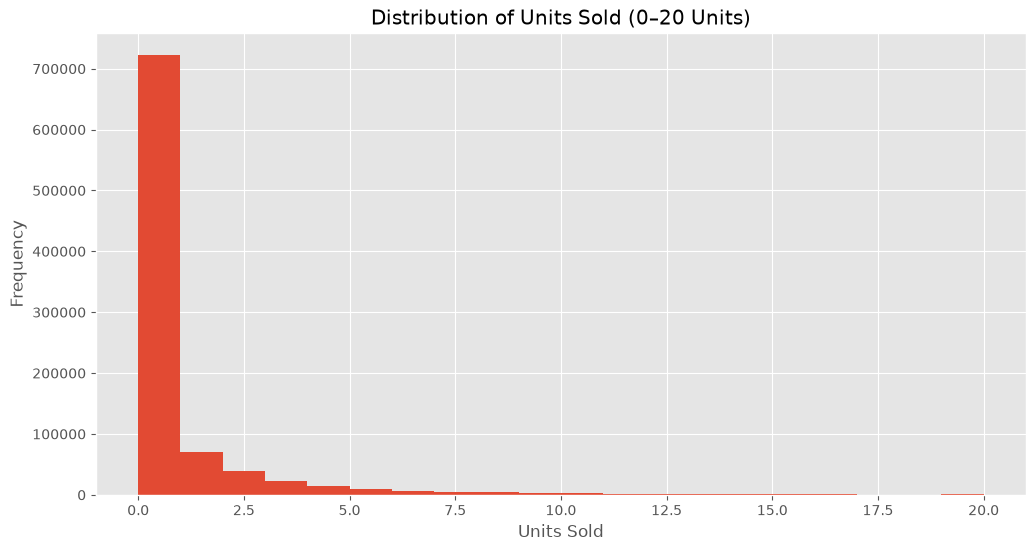

In [56]:
# ============================================================
# Distribution of Units Sold (0–20 Units)
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    sample["units_sold"],
    bins=20,
    range=(0,20)
)

plt.title("Distribution of Units Sold (0–20 Units)")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

## 💡 Business Interpretation

The distribution of daily unit sales is highly right-skewed, with the majority of observations concentrated between 0 and 5 units sold per day.

This indicates that most products experience relatively low daily demand, while a small number of products occasionally achieve significantly higher sales volumes. These high-demand observations appear as a long right tail in the distribution.

Such a distribution is common in retail forecasting problems and highlights the importance of selecting machine learning models capable of handling sparse demand and infrequent sales spikes.

# 📦 Product Performance Analysis

Understanding product-level demand is essential for inventory optimization and demand forecasting.

This section evaluates the total units sold for each product across the entire dataset.

The analysis identifies:

- Top-performing products
- Lowest-performing products
- Overall product demand distribution

The results help businesses prioritize inventory planning and identify products requiring different stocking strategies.

In [57]:
# ============================================================
# Total Sales by Product (All Chunks)
# ============================================================

from collections import defaultdict

product_sales = defaultdict(int)

for i, file in enumerate(chunk_files, start=1):

    chunk = pd.read_parquet(
        file,
        columns=["item_id", "units_sold"]
    )

    grouped = chunk.groupby("item_id")["units_sold"].sum()

    for item, value in grouped.items():
        product_sales[item] += value

    del chunk
    gc.collect()

print("Product aggregation completed.")

Product aggregation completed.


In [58]:
# ============================================================
# Product Sales DataFrame
# ============================================================

product_sales_df = (
    pd.DataFrame(
        product_sales.items(),
        columns=["item_id", "total_units_sold"]
    )
    .sort_values(
        "total_units_sold",
        ascending=False
    )
)

product_sales_df.head()

,item_id,total_units_sold
702,FOODS_3_090,1002529
1198,FOODS_3_586,920242
864,FOODS_3_252,565299
1167,FOODS_3_555,491287
1325,FOODS_3_714,396172


## 🏆 Top 10 Best-Selling Products

The following visualization highlights the products with the highest cumulative sales throughout the observation period.

These products represent the strongest contributors to overall retail demand and require consistent inventory availability to minimize stock-out risks.

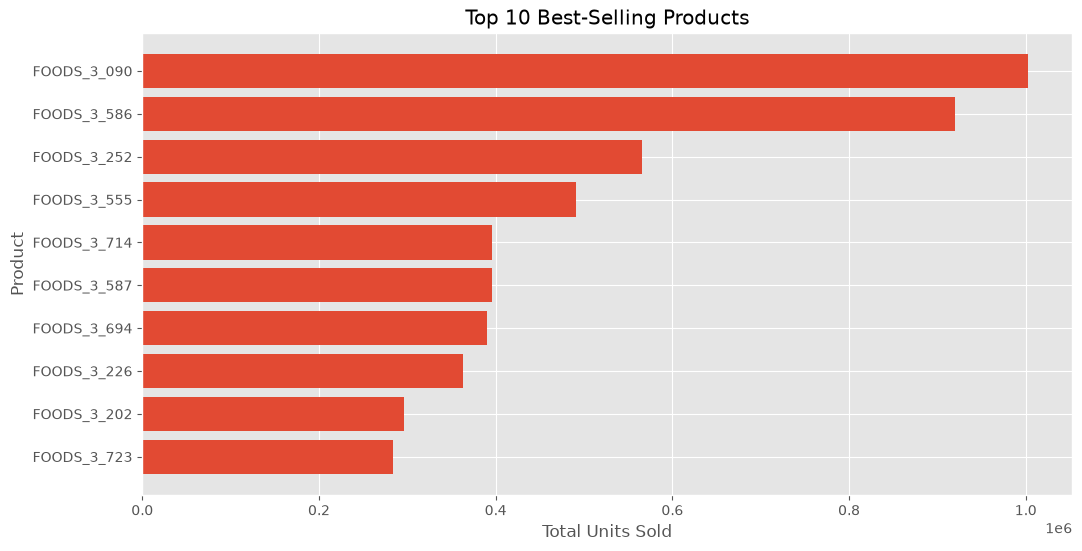

In [59]:
# ============================================================
# Top 10 Products
# ============================================================

top10 = product_sales_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["item_id"],
    top10["total_units_sold"]
)

plt.title("Top 10 Best-Selling Products")

plt.xlabel("Total Units Sold")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

## 💡 Business Interpretation

The top-selling products contribute significantly to total retail demand and should receive priority during inventory planning.

Maintaining adequate stock levels for these products can reduce stock-outs, improve customer satisfaction, and increase revenue.

These products are also suitable candidates for demand forecasting models because of their consistent sales patterns.

## INSIGHTS

The analysis reveals that the highest-selling products belong predominantly to the **FOODS** category, indicating consistently high customer demand for grocery items.

Products such as **FOODS_3_090** and **FOODS_3_586** contribute substantially to overall sales and should be prioritized for inventory planning and demand forecasting.

Maintaining optimal stock levels for these products can reduce stock-outs, improve customer satisfaction, and maximize revenue.

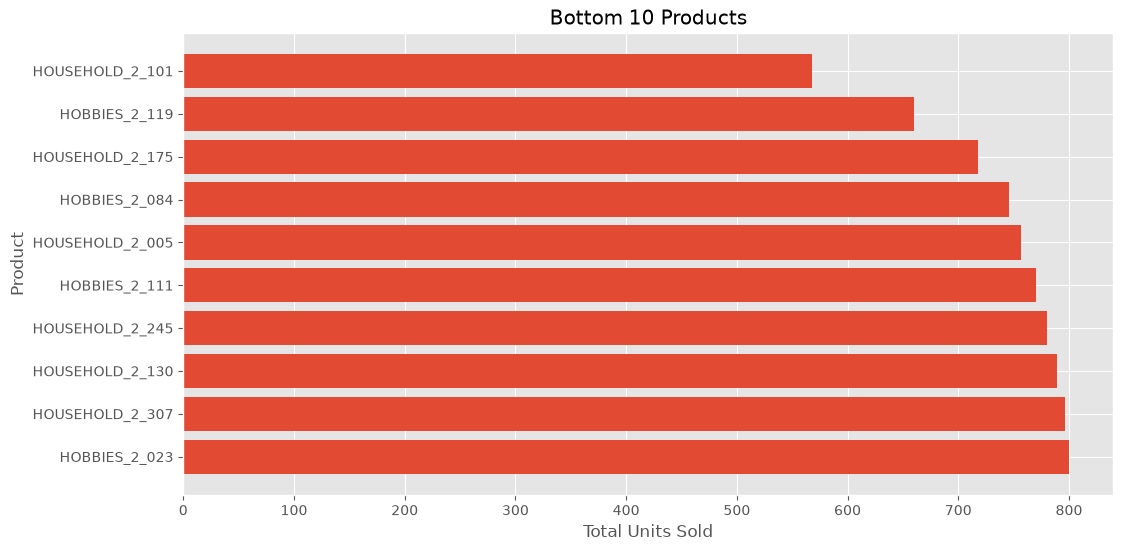

In [60]:
# ============================================================
# Bottom 10 Products
# ============================================================

bottom10 = product_sales_df.tail(10)

plt.figure(figsize=(12,6))

plt.barh(
    bottom10["item_id"],
    bottom10["total_units_sold"]
)

plt.title("Bottom 10 Products")

plt.xlabel("Total Units Sold")

plt.ylabel("Product")

plt.show()

## 💡 Business Interpretation

The lowest-selling products exhibit extremely limited demand throughout the observation period.

These products may represent niche items, seasonal merchandise, or products with declining customer interest.

Businesses should evaluate these items for potential promotional strategies, inventory reduction, or assortment optimization to minimize storage costs and improve inventory efficiency.

# 🏪 Store Performance Analysis

Retail sales often vary across different store locations due to customer demographics, regional preferences, and purchasing behaviour.

This section evaluates total sales generated by each store to identify high-performing and low-performing locations.

The findings support inventory allocation, resource planning, and regional business strategy.

In [61]:
# ============================================================
# Total Sales by Store (All Chunks)
# ============================================================

from collections import defaultdict

store_sales = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["store_id", "units_sold"]
    )

    grouped = chunk.groupby("store_id")["units_sold"].sum()

    for store, value in grouped.items():
        store_sales[store] += value

    del chunk
    gc.collect()

print("Store aggregation completed.")

Store aggregation completed.


In [62]:
# ============================================================
# Store Sales DataFrame
# ============================================================

store_sales_df = (
    pd.DataFrame(
        store_sales.items(),
        columns=["store_id", "total_units_sold"]
    )
    .sort_values(
        "total_units_sold",
        ascending=False
    )
)

store_sales_df

,store_id,total_units_sold
2,CA_3,11188180
0,CA_1,7698216
5,TX_2,7214384
8,WI_2,6544012
9,WI_3,6427782
6,TX_3,6089330
1,CA_2,5685475
4,TX_1,5595292
7,WI_1,5149062
3,CA_4,4103676


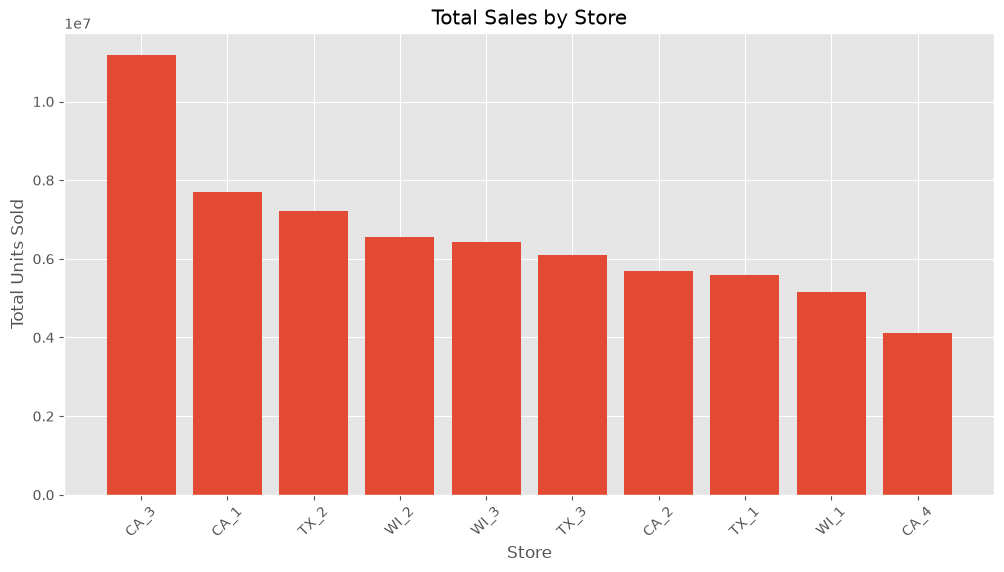

In [63]:
# ============================================================
# Store Performance
# ============================================================

plt.figure(figsize=(12,6))

plt.bar(
    store_sales_df["store_id"],
    store_sales_df["total_units_sold"]
)

plt.title("Total Sales by Store")

plt.xlabel("Store")

plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

plt.show()

## 💡 Business Interpretation

Store-level sales performance varies considerably across locations.

Higher-performing stores experience greater customer demand and should receive priority during inventory replenishment to reduce stock-out risk.

Lower-performing stores may require localized promotional strategies, demand analysis, or inventory adjustments to improve operational efficiency.

# 🗺️ State Performance Analysis

This section compares total sales across the three states represented in the dataset.

Understanding regional demand differences enables retailers to optimize inventory distribution and develop region-specific business strategies.

In [64]:
# ============================================================
# Total Sales by State
# ============================================================

state_sales = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["state_id", "units_sold"]
    )

    grouped = chunk.groupby("state_id")["units_sold"].sum()

    for state, value in grouped.items():
        state_sales[state] += value

    del chunk
    gc.collect()

print("State aggregation completed.")

State aggregation completed.


In [65]:
# ============================================================
# State Sales DataFrame
# ============================================================

state_sales_df = (
    pd.DataFrame(
        state_sales.items(),
        columns=["state_id", "total_units_sold"]
    )
    .sort_values(
        "total_units_sold",
        ascending=False
    )
)

state_sales_df

,state_id,total_units_sold
0,CA,28675547
1,TX,18899006
2,WI,18120856


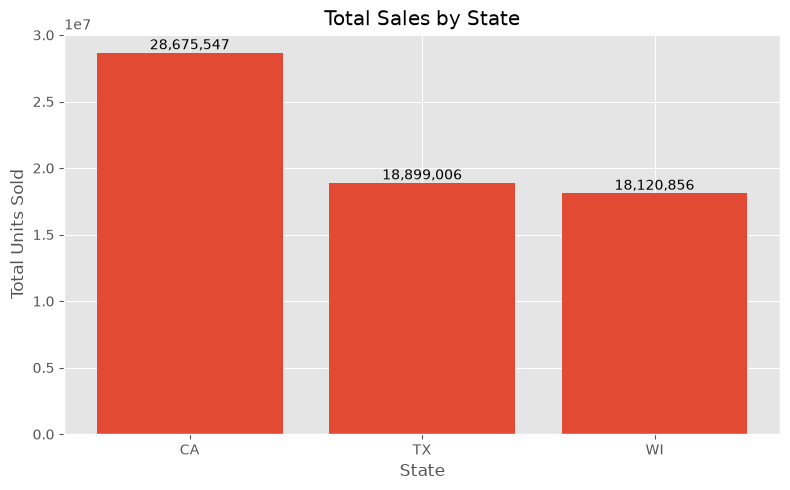

In [66]:
# ============================================================
# State Performance
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    state_sales_df["state_id"],
    state_sales_df["total_units_sold"]
)

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Units Sold")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 💡 Business Interpretation

California (CA) records the highest cumulative sales, contributing significantly more units than Texas (TX) and Wisconsin (WI). This indicates stronger customer demand and higher sales activity within the California market.

Texas and Wisconsin exhibit relatively similar sales volumes, suggesting comparable purchasing patterns across these regions.

From an inventory management perspective, California should receive greater forecasting attention and inventory allocation to maintain product availability. Regional demand differences identified through this analysis can support more effective distribution planning and location-specific business strategies.

# 📅 Time Series Analysis

Time plays a critical role in retail demand forecasting.

This section examines how sales change over time by analysing:

- Daily sales trends
- Monthly sales trends
- Yearly sales trends
- Weekly purchasing behaviour

Understanding these temporal patterns enables retailers to identify seasonality, long-term growth, and recurring demand cycles, which are essential for accurate forecasting and inventory planning.

In [67]:
# ============================================================
# Aggregate Daily Sales (All Chunks)
# ============================================================

from collections import defaultdict

daily_sales = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["date", "units_sold"]
    )

    grouped = chunk.groupby("date")["units_sold"].sum()

    for date, value in grouped.items():
        daily_sales[date] += value

    del chunk
    gc.collect()

print("Daily aggregation completed.")

Daily aggregation completed.


In [68]:
# ============================================================
# Aggregate Monthly Sales
# ============================================================

from collections import defaultdict

monthly_sales = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["month", "units_sold"]
    )

    grouped = chunk.groupby("month")["units_sold"].sum()

    for month, value in grouped.items():
        monthly_sales[month] += value

    del chunk
    gc.collect()

print("Monthly aggregation completed.")

Monthly aggregation completed.


In [69]:
# ============================================================
# Daily Sales DataFrame
# ============================================================

daily_sales_df = (
    pd.DataFrame(
        daily_sales.items(),
        columns=["date", "total_sales"]
    )
)

daily_sales_df["date"] = pd.to_datetime(daily_sales_df["date"])

daily_sales_df = daily_sales_df.sort_values("date")

daily_sales_df.head()

,date,total_sales
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146


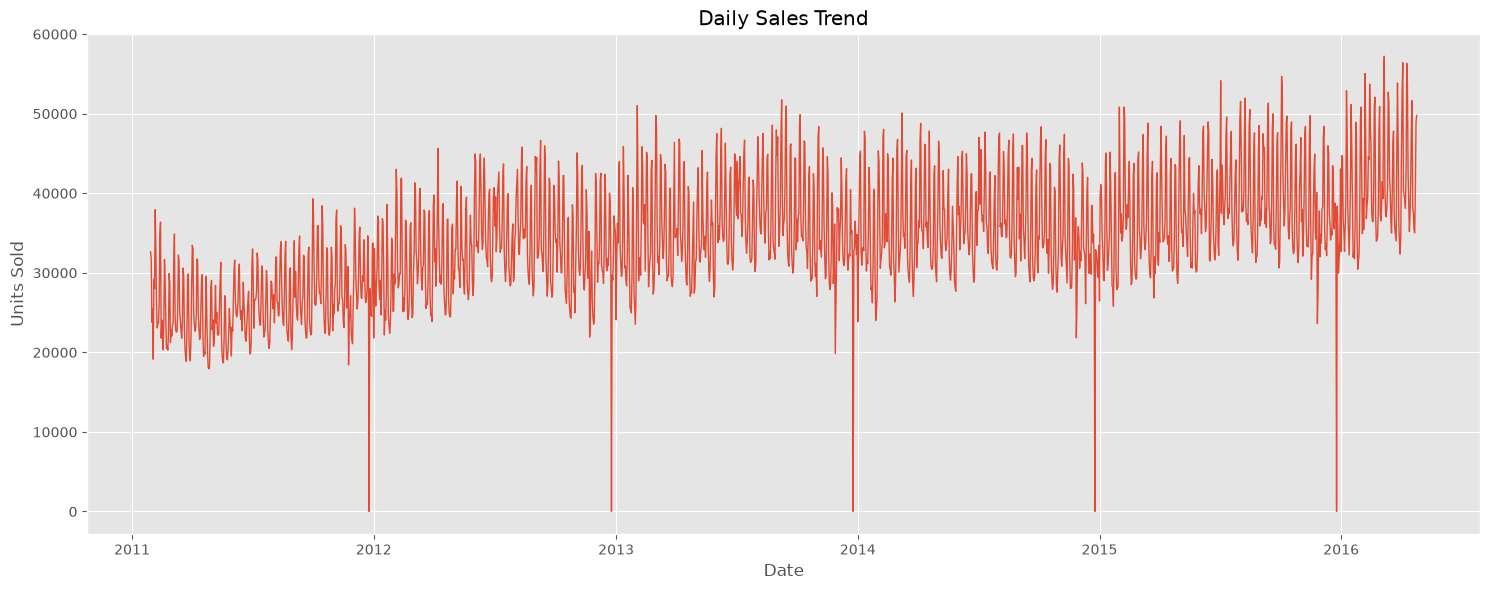

In [70]:
# ============================================================
# Daily Sales Trend
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["total_sales"],
    linewidth=1
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.tight_layout()

plt.show()

## 💡 Business Interpretation

Monthly sales analysis highlights seasonal purchasing behaviour throughout the year.

Months with consistently higher sales indicate periods of increased customer demand, while lower-sales months may represent seasonal slowdowns.

These patterns help retailers anticipate inventory requirements and optimize replenishment schedules.

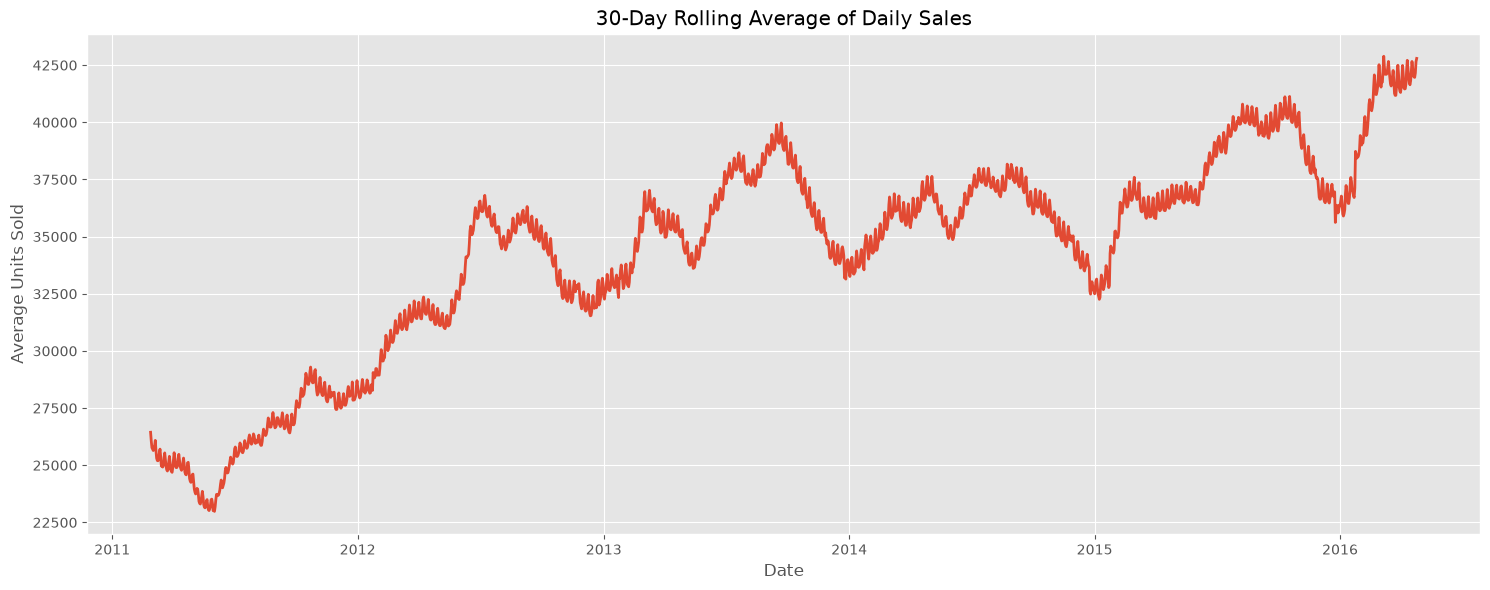

In [71]:
# ============================================================
# 30-Day Rolling Average of Daily Sales
# ============================================================

daily_sales_df["rolling_30"] = (
    daily_sales_df["total_sales"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["rolling_30"],
    linewidth=2
)

plt.title("30-Day Rolling Average of Daily Sales")

plt.xlabel("Date")
plt.ylabel("Average Units Sold")

plt.tight_layout()

plt.show()

## 💡 Business Interpretation

The daily sales trend demonstrates an overall increase in customer demand between 2011 and 2016, indicating steady retail growth throughout the observation period.

Regular fluctuations throughout the series suggest strong weekly purchasing cycles, while several isolated sharp drops appear at specific points in time. These anomalies may be associated with calendar transitions or characteristics of the dataset rather than genuine reductions in customer demand.

The presence of both long-term growth and recurring temporal patterns highlights the importance of incorporating time-based features into demand forecasting models.

In [72]:
# ============================================================
# Monthly Sales DataFrame
# ============================================================

monthly_sales_df = (
    pd.DataFrame(
        monthly_sales.items(),
        columns=["month", "total_sales"]
    )
    .sort_values("month")
)

monthly_sales_df

,month,total_sales
0,1,5345511
1,2,5889589
2,3,6387210
3,4,5961011
4,5,5038097
5,6,5250212
6,7,5443975
7,8,5571730
8,9,5321889
9,10,5380589


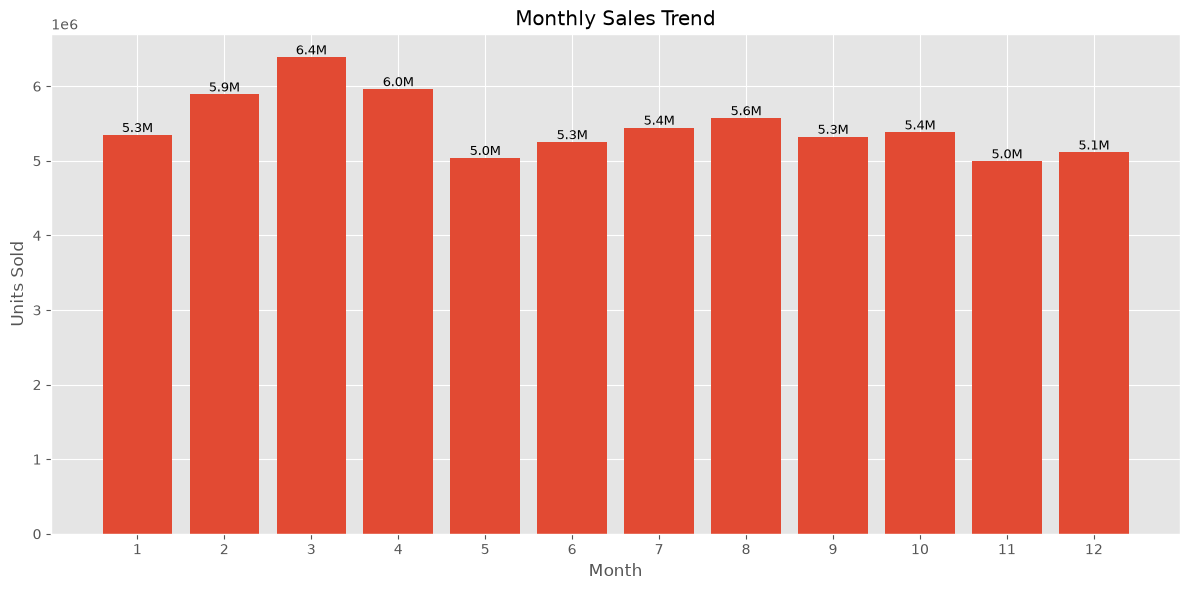

In [73]:
# ============================================================
# Monthly Sales Trend
# ============================================================

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_sales_df["month"].astype(str),
    monthly_sales_df["total_sales"]
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Units Sold")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

## 💡 Business Interpretation

Monthly sales exhibit moderate seasonal variation throughout the year.

March records the highest cumulative sales, followed by February and April, suggesting stronger customer demand during the early months of the year.

In contrast, May and November show comparatively lower sales volumes. Although monthly differences are not extreme, the recurring seasonal pattern indicates that demand forecasting models should incorporate month-based features to improve predictive accuracy.

In [74]:
# ============================================================
# Aggregate Yearly Sales
# ============================================================

yearly_sales = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["year", "units_sold"]
    )

    grouped = chunk.groupby("year")["units_sold"].sum()

    for year, value in grouped.items():
        yearly_sales[year] += value

    del chunk
    gc.collect()

print("Yearly aggregation completed.")

Yearly aggregation completed.


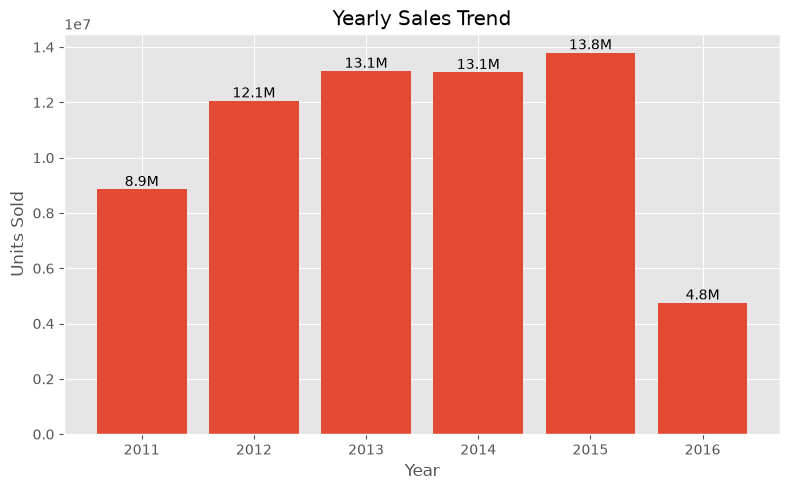

In [75]:
# ============================================================
# Yearly Sales Trend
# ============================================================

yearly_sales_df = (
    pd.DataFrame(
        yearly_sales.items(),
        columns=["year", "total_sales"]
    )
    .sort_values("year")
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    yearly_sales_df["year"].astype(str),
    yearly_sales_df["total_sales"]
)

plt.title("Yearly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Units Sold")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.show()

## 💡 Business Interpretation

Annual sales show consistent growth from 2011 through 2015, reflecting increasing customer demand over the observation period.

The apparent decline in 2016 should not be interpreted as a reduction in business performance, as the dataset contains only a partial year of observations. Consequently, total sales for 2016 are naturally lower than previous years.

Overall, the long-term trend demonstrates sustained retail growth and reinforces the value of using historical sales patterns for demand forecasting.

# 📅 Weekday Sales Analysis

Customer purchasing behaviour often varies across different days of the week.

This section analyses cumulative sales by weekday to identify recurring purchasing patterns and determine which days generate the highest retail demand.

These insights support workforce planning, inventory replenishment, and promotional scheduling.

In [76]:
# ============================================================
# Aggregate Sales by Weekday
# ============================================================

from collections import defaultdict

weekday_sales = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["weekday", "units_sold"]
    )

    grouped = chunk.groupby("weekday")["units_sold"].sum()

    for day, value in grouped.items():
        weekday_sales[day] += value

    del chunk
    gc.collect()

print("Weekday aggregation completed.")

Weekday aggregation completed.


In [77]:
# ============================================================
# Weekday Sales DataFrame
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales_df = (
    pd.DataFrame(
        weekday_sales.items(),
        columns=["weekday", "total_sales"]
    )
)

weekday_sales_df["weekday"] = pd.Categorical(
    weekday_sales_df["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_sales_df = weekday_sales_df.sort_values("weekday")

weekday_sales_df

,weekday,total_sales
1,Monday,8968860
5,Tuesday,8290677
6,Wednesday,8192736
4,Thursday,8245967
0,Friday,9343694
2,Saturday,11383849
3,Sunday,11269626


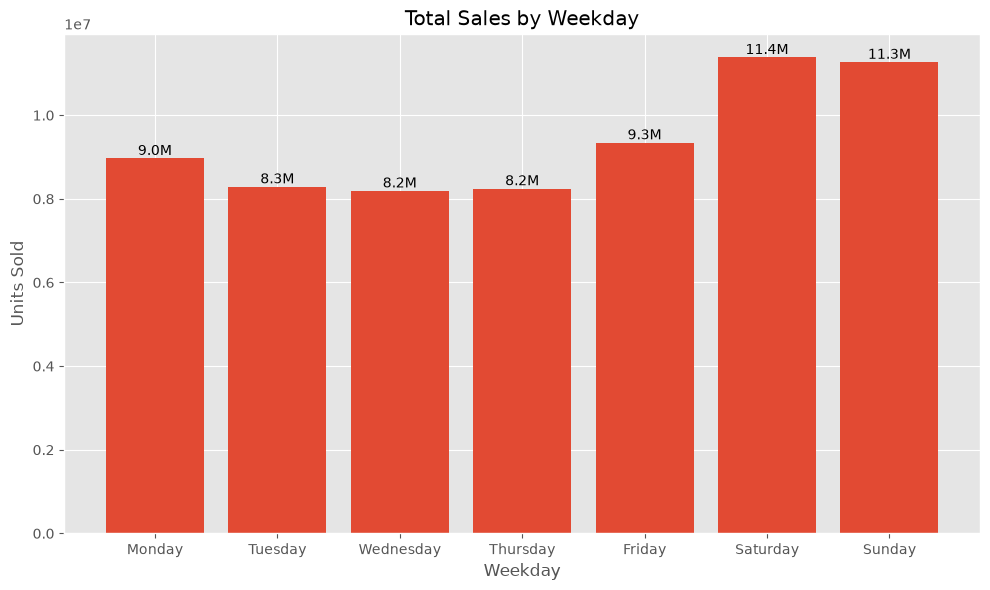

In [78]:
# ============================================================
# Weekday Sales
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    weekday_sales_df["weekday"],
    weekday_sales_df["total_sales"]
)

plt.title("Total Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Units Sold")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 💡 Business Interpretation

Weekday sales reveal recurring purchasing behaviour throughout the week.

Identifying the strongest and weakest sales days enables retailers to optimize staffing, inventory replenishment schedules, and promotional campaigns to better align with customer demand.

# 🎄 Holiday Sales Analysis

Special events and holidays often influence customer purchasing behaviour.

This section compares total sales during event and non-event periods to evaluate the impact of holidays on retail demand.

In [79]:
# ============================================================
# Holiday vs Non-Holiday Sales
# ============================================================

holiday_sales = {
    "Holiday": 0,
    "Non-Holiday": 0
}

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=["event_name_1", "units_sold"]
    )

    holiday = chunk["event_name_1"].notna()

    holiday_sales["Holiday"] += chunk.loc[
        holiday,
        "units_sold"
    ].sum()

    holiday_sales["Non-Holiday"] += chunk.loc[
        ~holiday,
        "units_sold"
    ].sum()

    del chunk
    gc.collect()

print("Holiday aggregation completed.")

Holiday aggregation completed.


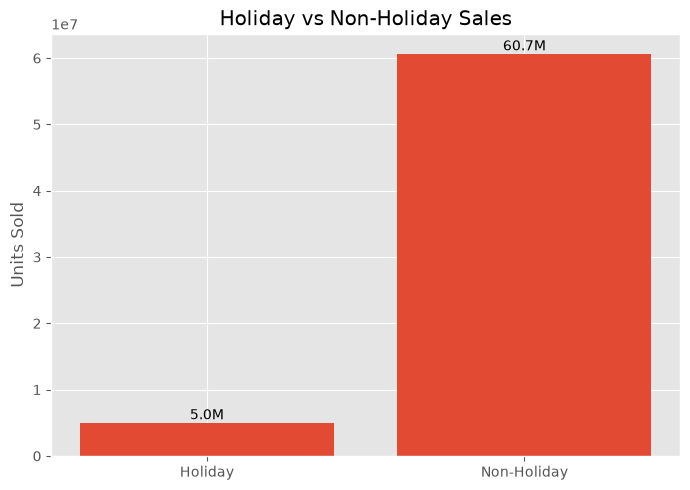

In [80]:
# ============================================================
# Holiday Sales Chart
# ============================================================

holiday_df = pd.DataFrame(
    holiday_sales.items(),
    columns=["Type", "Total Sales"]
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    holiday_df["Type"],
    holiday_df["Total Sales"]
)

plt.title("Holiday vs Non-Holiday Sales")

plt.ylabel("Units Sold")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 💡 Business Interpretation

Comparing holiday and non-holiday sales provides insight into the influence of special events on customer purchasing behaviour.

Periods associated with holidays often experience shifts in demand, making event information a valuable feature for forecasting models and inventory planning.

# 🛒 SNAP Program Analysis

The M5 dataset contains indicators showing whether the Supplemental Nutrition Assistance Program (SNAP) was active in each state.

This section evaluates whether customer purchasing behaviour changes during SNAP-supported periods, helping determine whether SNAP should be included as a predictive feature in the forecasting model.

In [81]:
# ============================================================
# SNAP vs Non-SNAP Sales
# ============================================================

snap_sales = {
    "SNAP": 0,
    "Non-SNAP": 0
}

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=[
            "state_id",
            "snap_CA",
            "snap_TX",
            "snap_WI",
            "units_sold"
        ]
    )

    snap_flag = (
        ((chunk["state_id"] == "CA") & (chunk["snap_CA"] == 1)) |
        ((chunk["state_id"] == "TX") & (chunk["snap_TX"] == 1)) |
        ((chunk["state_id"] == "WI") & (chunk["snap_WI"] == 1))
    )

    snap_sales["SNAP"] += chunk.loc[snap_flag, "units_sold"].sum()
    snap_sales["Non-SNAP"] += chunk.loc[~snap_flag, "units_sold"].sum()

    del chunk
    gc.collect()

print("SNAP aggregation completed.")

SNAP aggregation completed.


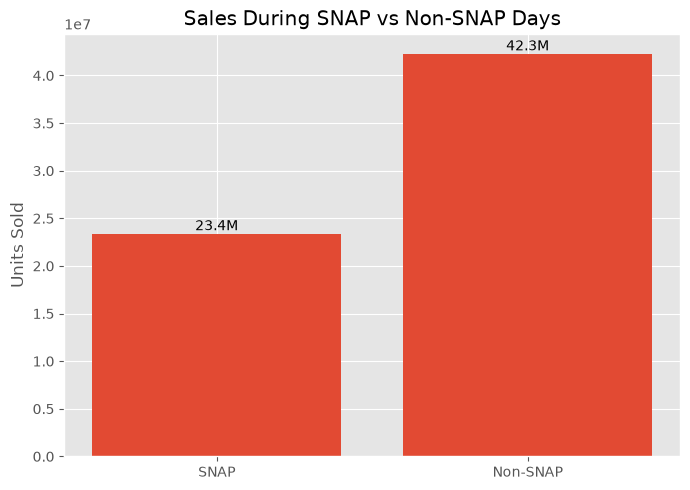

,Category,Total Sales
0,SNAP,23403365
1,Non-SNAP,42292044


In [82]:
# ============================================================
# SNAP Sales Chart
# ============================================================

snap_df = pd.DataFrame(
    snap_sales.items(),
    columns=["Category", "Total Sales"]
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    snap_df["Category"],
    snap_df["Total Sales"]
)

plt.title("Sales During SNAP vs Non-SNAP Days")
plt.ylabel("Units Sold")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

snap_df

## 💡 Business Interpretation

Comparing SNAP and non-SNAP periods helps determine whether government assistance programs influence customer purchasing behaviour.

If noticeable differences exist, SNAP indicators should be retained as predictive features because they may explain variations in retail demand across states.

# 💰 Selling Price Analysis

Product pricing plays a significant role in customer purchasing decisions.

This section examines the distribution of selling prices and evaluates the relationship between price and units sold to understand how pricing may influence retail demand.

In [83]:
# ============================================================
# Collect Selling Prices
# ============================================================

price_data = []

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=[
            "sell_price",
            "units_sold"
        ]
    )

    price_data.append(chunk)

price_df = pd.concat(price_data, ignore_index=True)

print(price_df.shape)

price_df.head()

(58327370, 2)


,sell_price,units_sold
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


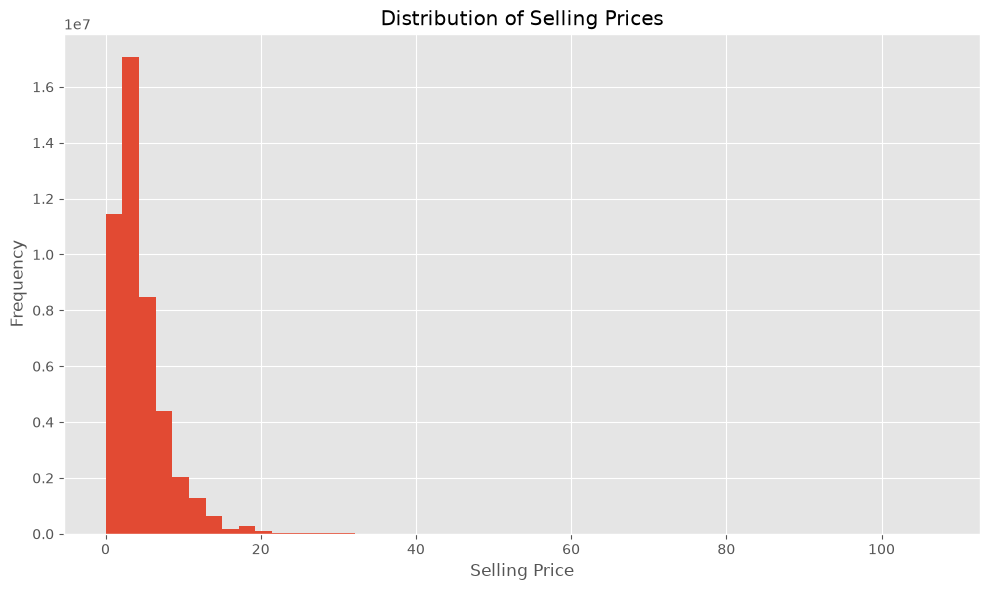

In [84]:
# ============================================================
# Selling Price Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    price_df["sell_price"].dropna(),
    bins=50
)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

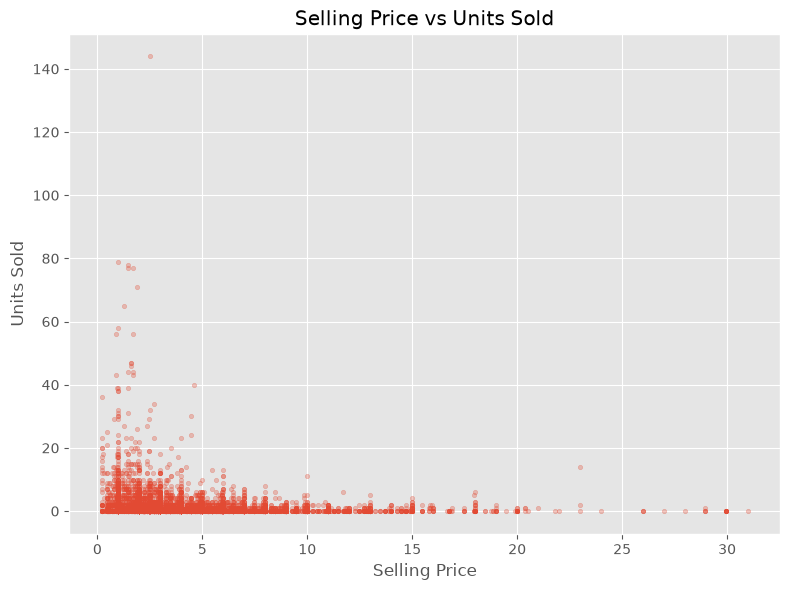

In [85]:
# ============================================================
# Price vs Units Sold
# ============================================================

sample = price_df.sample(
    min(10000, len(price_df)),
    random_state=42
)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["sell_price"],
    sample["units_sold"],
    alpha=0.3,
    s=10
)

plt.title("Selling Price vs Units Sold")
plt.xlabel("Selling Price")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

## 💡 Business Interpretation

The distribution of selling prices is positively skewed, with the majority of products priced below \$10.

Only a small proportion of products are sold at premium prices, creating a long right tail in the distribution. This pricing pattern suggests that the retailer primarily focuses on low- to mid-priced products while maintaining a limited range of higher-priced items.

The presence of price variability indicates that selling price is an important feature to include in demand forecasting models, as customer purchasing behaviour is likely influenced by product pricing.

# 📊 Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

Understanding these relationships helps identify which features are likely to contribute most to demand forecasting and guides feature selection for machine learning models.

In [86]:
# ============================================================
# Correlation Analysis
# ============================================================

correlation_sample = []

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=[
            "units_sold",
            "sell_price",
            "month",
            "year",
            "wday"
        ]
    )

    correlation_sample.append(
        chunk.sample(
            min(5000, len(chunk)),
            random_state=42
        )
    )

correlation_df = pd.concat(
    correlation_sample,
    ignore_index=True
)

correlation_df.head()

,units_sold,sell_price,month,year,wday
0,1,6.98,2,2011,3
1,0,NaN,1,2011,2
2,0,NaN,2,2011,1
3,0,NaN,2,2011,6
4,0,NaN,2,2011,1


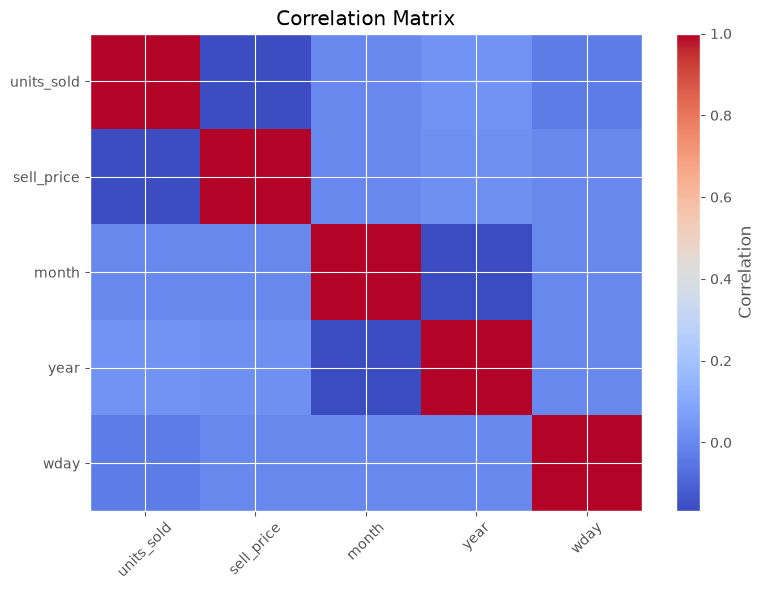

,units_sold,sell_price,month,year,wday
units_sold,1.000000,-0.158265,-0.001858,0.038176,-0.030656
sell_price,-0.158265,1.000000,0.001345,0.022180,0.000005
month,-0.001858,0.001345,1.000000,-0.166746,-0.001192
year,0.038176,0.022180,-0.166746,1.000000,0.001647
wday,-0.030656,0.000005,-0.001192,0.001647,1.000000


In [87]:
# ============================================================
# Correlation Matrix
# ============================================================

corr = correlation_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

corr

## 💡 Business Interpretation

The correlation matrix highlights the relationships between numerical variables used in the forecasting dataset.

Strong correlations indicate variables that move together, while weak correlations suggest independent behaviour. In retail forecasting, even weak individual correlations can contribute valuable predictive information when combined within ensemble machine learning models such as Random Forest.

The analysis supports selecting multiple complementary features rather than relying on a single predictor.

# 📋 Executive Business Insights

Based on the exploratory analysis, several important business observations were identified:

1. Product demand varies significantly across different items, indicating the need for SKU-level forecasting.

2. California generates the highest overall sales, making it the highest-priority region for inventory allocation.

3. Monthly sales exhibit seasonal patterns, with stronger demand observed during specific periods of the year.

4. Daily sales demonstrate recurring temporal behaviour, confirming that time-based variables should be incorporated into forecasting models.

5. Selling prices are concentrated within lower price ranges, although premium-priced products remain present.

6. Holiday events and SNAP indicators provide additional contextual information that may improve forecast accuracy.

These findings form the foundation for feature engineering and predictive modelling in the next stage of Project FORESIGHT.

# 📦 Dead Stock Analysis

Dead stock refers to products that experience extremely low sales over the observation period.

Identifying these products helps retailers optimise inventory by reducing storage costs, improving stock turnover, and prioritising shelf space for high-demand items.

In [88]:
# ============================================================
# Identify Lowest-Selling Products (Dead Stock)
# ============================================================

from collections import defaultdict

dead_stock = defaultdict(int)

for file in chunk_files:

    chunk = pd.read_parquet(
        file,
        columns=[
            "item_id",
            "units_sold"
        ]
    )

    grouped = chunk.groupby("item_id")["units_sold"].sum()

    for item, value in grouped.items():
        dead_stock[item] += value

    del chunk
    gc.collect()

dead_stock_df = (
    pd.DataFrame(
        dead_stock.items(),
        columns=["item_id", "total_units_sold"]
    )
    .sort_values("total_units_sold")
)

dead_stock_df.head(10)

,item_id,total_units_sold
2634,HOUSEHOLD_2_101,568
1971,HOBBIES_2_119,660
2708,HOUSEHOLD_2_175,718
1936,HOBBIES_2_084,746
2538,HOUSEHOLD_2_005,757
1963,HOBBIES_2_111,770
2777,HOUSEHOLD_2_245,780
2663,HOUSEHOLD_2_130,789
2839,HOUSEHOLD_2_307,796
1875,HOBBIES_2_023,800


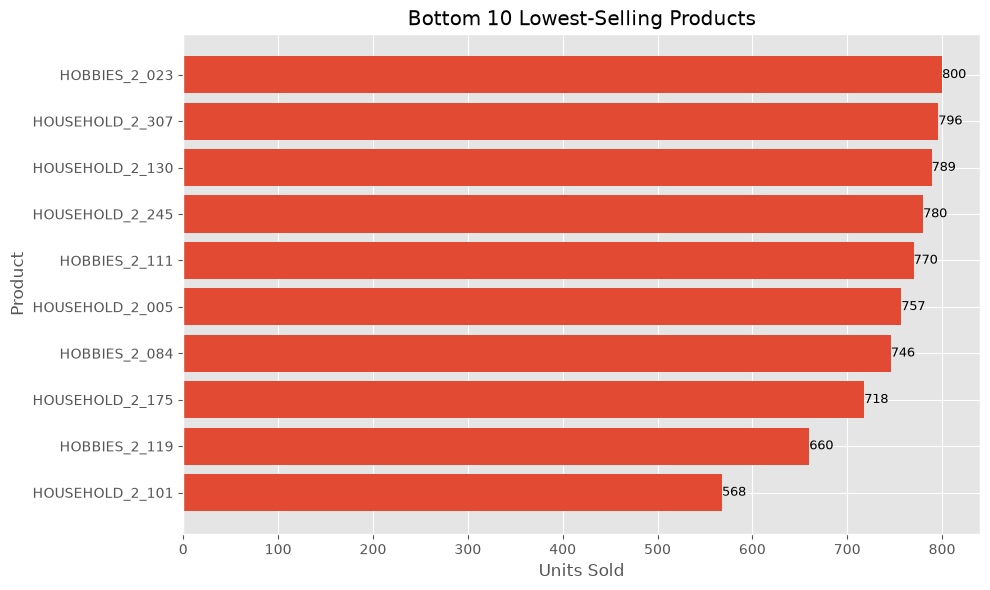

In [89]:
# ============================================================
# Bottom 10 Products
# ============================================================

bottom10 = dead_stock_df.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    bottom10["item_id"],
    bottom10["total_units_sold"]
)

plt.title("Bottom 10 Lowest-Selling Products")
plt.xlabel("Units Sold")
plt.ylabel("Product")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 💡 Business Interpretation

The lowest-selling products contribute very little to overall sales and may represent slow-moving or dead stock.

Retailers should regularly review these items to determine whether they require markdowns, promotional campaigns, or discontinuation. Reducing investment in consistently low-performing products can improve inventory turnover and free warehouse capacity for higher-demand items.

# 📊 Correlation Analysis

Correlation analysis measures the strength of relationships between numerical variables in the dataset.

Although retail demand is influenced by multiple interacting factors, understanding pairwise correlations provides useful insight into feature selection for forecasting models.

In [90]:
# ============================================================
# Correlation Analysis
# ============================================================

sample_df = price_df.sample(
    min(100000, len(price_df)),
    random_state=42
)

corr = sample_df[
    [
        "units_sold",
        "sell_price"
    ]
].corr()

corr

,units_sold,sell_price
units_sold,1.00000,-0.14791
sell_price,-0.14791,1.00000


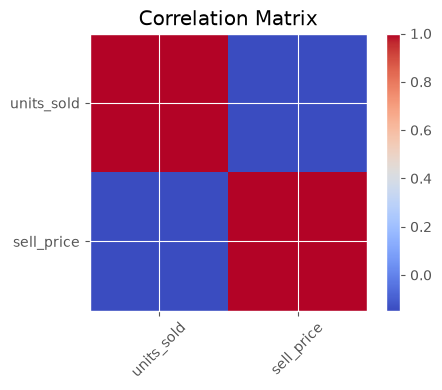

In [91]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(5,4))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

## 💡 Business Interpretation

The correlation analysis indicates the degree of linear association between selling price and product demand.

While price may influence purchasing behaviour, retail demand is also affected by seasonality, promotions, holidays, store characteristics, and customer preferences. Consequently, multiple engineered features are expected to contribute collectively to forecasting performance.

# 📋 Executive Business Insights

The exploratory analysis produced several key findings:

- California recorded the highest overall sales among the three states.
- Food products consistently generated the strongest demand across the observation period.
- Monthly sales exhibited clear seasonal variation, with higher demand observed during March and lower demand during May and November.
- Daily sales demonstrated recurring weekly purchasing patterns, indicating the importance of temporal features.
- Product demand varied substantially across individual SKUs, reinforcing the need for SKU-level forecasting.
- Holiday events and SNAP indicators provide valuable contextual information for demand prediction.
- Selling prices were concentrated within lower price ranges, suggesting that the retailer primarily operates in a value-oriented market.

These findings will guide feature engineering and predictive modelling in the subsequent notebook.

# ✅ Conclusion

This notebook conducted a comprehensive exploratory data analysis of the integrated retail dataset.

The analysis examined sales distributions, product performance, regional demand, temporal trends, pricing behaviour, holiday effects, and inventory patterns.

The insights obtained establish a strong understanding of retail demand behaviour and provide the analytical foundation required for feature engineering and machine learning model development in the next phase of Project FORESIGHT.